In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3

pd.options.mode.chained_assignment = None 

# --- 1. CODESPACES PATHING (SOP) ---
PROJECT_ROOT = "/workspaces/pienza"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
DUMP_DIR = os.path.join(DATA_DIR, "dumped_files")
DB_PATH = os.path.join(DATA_DIR, "pienza.db")

# --- 2. CONNECTIVITY ---
if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 3. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY, 'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT, 'xtick.color': '#333333', 'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD', 'grid.color': '#E0E0E0', 'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE, 'axes.titleweight': 'bold',
    'figure.titlesize': 24, 'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print(f"✅ SOP Ready: Output set to {DUMP_DIR}")

✅ Database found: /workspaces/pienza/data/pienza.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).
✅ SOP Ready: Output set to /workspaces/pienza/data/dumped_files


In [2]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (MASTER VERSION - CLEAN & FORGED)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
# Insertamos el filtro AQUÍ para que todo lo downstream esté sincronizado.
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Dynamic 90% Variance)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_wide_pca = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (Scaled only)
scaler_b = StandardScaler()
X_praetorian_final_raw = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=praetorian_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Dynamic 90% Variance)
pca_c = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_praetorian_pca = pd.DataFrame(pca_c.fit_transform(X_praetorian_final_raw), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_wide_pca.shape}  -> {X_wide_pca.shape[1]} PCs (90% Var)")
print(f"✅ LIGA B (Praetorian Raw): {X_praetorian_final_raw.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_praetorian_pca.shape}  -> {X_praetorian_pca.shape[1]} PCs (90% Var)")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---")

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
✅ LIGA A (Wide PCA):       (4760, 19)  -> 19 PCs (90% Var)
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 PCs (90% Var)

--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---


In [3]:
'''# ==============================================================================
# CELL 1: THE DATA FOUNDRY (EXPLICIT UNIVERSES A & B)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# ... (Después de cargar df_input)

# --- 1.5 SANITY FILTER: DROPPING RARE CLASSES ---
# Class 7 (system_logic_failure) tiene N < 10. Es ruido.
print(f"📉 Rows before filtering Class 7: {len(df_input)}")

# Asumiendo que el ID en la base de datos es el 7 (según tu lista)
# Si el ID real en la DB es otro, ajusta el número.
df_input = df_input[df_input['reason_primary_fk'] != 7]

print(f"✅ Rows after filtering: {len(df_input)}")

# ... (Continúa con TARGET PREPARATION)

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. UNIVERSO A: THE WIDE HORIZON (41 FEATURES)
# Propósito: Máxima información. Incluye redundancias y "casualties" de Lasso.
# ==============================================================================
universo_a_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# ==============================================================================
# 4. UNIVERSO B: THE PRAETORIAN GUARD (20 FEATURES)
# Propósito: Selección estratégica del experto. 20 sobrevivientes ratificados.
# ==============================================================================
universo_b_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 5. CLEANING & NUMERIC CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, universo_a_list)
X_b_raw = prepare_matrix(df_input, universo_b_list)

# --- 6. LOG TRANSFORMATIONS (Yesterday's Strategic Recipe) ---
# Aplicamos log1p solo a variables de magnitud (Money, Time, Distance, Traffic)
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 7. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Comprimiendo 41 vars -> 21 PCs para el 90% de Varianza)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=21, random_state=42)
X_league_a = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (20 vars escaladas pero sin PCA para mantener interpretabilidad)
scaler_b = StandardScaler()
X_league_b = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=universo_b_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Comprimiendo 20 vars -> 12 PCs para el 90% de Varianza)
pca_c = PCA(n_components=12, random_state=42)
X_league_c = pd.DataFrame(pca_c.fit_transform(X_league_b), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_league_a.shape}  -> 21 Components")
print(f"✅ LIGA B (Praetorian Raw): {X_league_b.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_league_c.shape}  -> 12 Components")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR THE BATTLE OF BAYES ---")'''

'# ==============================================================================\n# CELL 1: THE DATA FOUNDRY (EXPLICIT UNIVERSES A & B)\n# ==============================================================================\nfrom sklearn.decomposition import PCA\nfrom sklearn.preprocessing import StandardScaler, LabelEncoder\nfrom IPython.display import display, Markdown\n\nprint("⏳ Ingesting v_ML_Supervised and forging analytical universes...")\n\n# 1. MASTER INGESTION\nquery = "SELECT * FROM v_ML_Supervised"\ndf_input = pd.read_sql(query, db_engine)\ndf_input = df_input.loc[:, ~df_input.columns.duplicated()]\n\n# ... (Después de cargar df_input)\n\n# --- 1.5 SANITY FILTER: DROPPING RARE CLASSES ---\n# Class 7 (system_logic_failure) tiene N < 10. Es ruido.\nprint(f"📉 Rows before filtering Class 7: {len(df_input)}")\n\n# Asumiendo que el ID en la base de datos es el 7 (según tu lista)\n# Si el ID real en la DB es otro, ajusta el número.\ndf_input = df_input[df_input[\'reason_primary_fk\'] !

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rows before filtering Class 7: 4765
✅ Rows after filtering: 4760
✅ LIGA A (Wide PCA):       (4760, 21)  -> 21 Components
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 Components

In [3]:
# ==============================================================================
# CELL 1.5: EXPECTATION CALIBRATION (THE "DRUNK MONKEY" THEOREM)
# ==============================================================================
from IPython.display import display, Markdown

calibration_msg = """
# 🧠 CALIBRACIÓN DE EXPECTATIVAS: Antes de ver los números...

Arquitecto, no te infartes si ves números que parecen "bajos" (como 0.40). En el mundo Multiclase Desbalanceado, las reglas de la escuela no aplican.

### **1. ¿Qué es "El Azar" (The Floor)?**
Imagina un **Mono Borracho** 🐒 sentado frente a tu computadora clasificando viajes.
*   Tienes **6 clases** (`Accepted`, `D_NonOp`, `D_SM`, `EEUM`, `Low_Profit`, `System`).
*   **Acierto Aleatorio:** Si el mono aprieta botones al azar, le atinará 1 de cada 6 veces (**~16%**).
*   **La Trampa de la Mayoría:** Si el mono es "listo" y siempre presiona el botón más grande (`D_NonOp`, el 50% de tus datos), tendrá una **Accuracy del 50%**.
*   **PERO...** Su **F1-Macro será terrible (casi 0.10)** porque estará ignorando por completo a las 5 clases pequeñas que nos importan.
    *   *Conclusión:* El "Suelo" real para F1-Macro es **0.10 - 0.15**.

### **2. ¿Qué es "Decente" para Naive Bayes?**
Naive Bayes es un modelo simple (lineal y probabilístico). No esperamos que sea un genio táctico.
*   Si Bayes te da un **F1-Macro de 0.30 o 0.40**, ¡eso ya es **EL DOBLE o TRIPLE** que el azar!
*   **Significado:** Eso confirma que **HAY SEÑAL**. Tus variables pretorianas sirven para distinguir realidades, no son ruido.

### **3. La Escala de Evaluación (F1-Macro)**
Recuerda: F1-Macro es la métrica más "cruel". Para sacar 1.0, tienes que ser perfecto incluso en las clases más difíciles y pequeñas.

*   🔴 **0.20:** Preocúpate. (Apenas mejor que el mono).
*   🟡 **0.40:** Alégrate. (Hay señal fuerte y estructura clara).
*   🟢 **0.60+:** Destapa el champán. (Resultado increíble para un primer intento simple).

> **🐑 Master Dolly dice:** *"No juzgues al pez por su habilidad para trepar árboles. Naive Bayes está aquí para decirnos si el mapa es correcto, no para ganar la carrera final. Si superamos el 0.35, tenemos luz verde para XGBoost."*
"""

display(Markdown(calibration_msg))


# 🧠 CALIBRACIÓN DE EXPECTATIVAS: Antes de ver los números...

Arquitecto, no te infartes si ves números que parecen "bajos" (como 0.40). En el mundo Multiclase Desbalanceado, las reglas de la escuela no aplican.

### **1. ¿Qué es "El Azar" (The Floor)?**
Imagina un **Mono Borracho** 🐒 sentado frente a tu computadora clasificando viajes.
*   Tienes **6 clases** (`Accepted`, `D_NonOp`, `D_SM`, `EEUM`, `Low_Profit`, `System`).
*   **Acierto Aleatorio:** Si el mono aprieta botones al azar, le atinará 1 de cada 6 veces (**~16%**).
*   **La Trampa de la Mayoría:** Si el mono es "listo" y siempre presiona el botón más grande (`D_NonOp`, el 50% de tus datos), tendrá una **Accuracy del 50%**.
*   **PERO...** Su **F1-Macro será terrible (casi 0.10)** porque estará ignorando por completo a las 5 clases pequeñas que nos importan.
    *   *Conclusión:* El "Suelo" real para F1-Macro es **0.10 - 0.15**.

### **2. ¿Qué es "Decente" para Naive Bayes?**
Naive Bayes es un modelo simple (lineal y probabilístico). No esperamos que sea un genio táctico.
*   Si Bayes te da un **F1-Macro de 0.30 o 0.40**, ¡eso ya es **EL DOBLE o TRIPLE** que el azar!
*   **Significado:** Eso confirma que **HAY SEÑAL**. Tus variables pretorianas sirven para distinguir realidades, no son ruido.

### **3. La Escala de Evaluación (F1-Macro)**
Recuerda: F1-Macro es la métrica más "cruel". Para sacar 1.0, tienes que ser perfecto incluso en las clases más difíciles y pequeñas.

*   🔴 **0.20:** Preocúpate. (Apenas mejor que el mono).
*   🟡 **0.40:** Alégrate. (Hay señal fuerte y estructura clara).
*   🟢 **0.60+:** Destapa el champán. (Resultado increíble para un primer intento simple).

> **🐑 Master Dolly dice:** *"No juzgues al pez por su habilidad para trepar árboles. Naive Bayes está aquí para decirnos si el mapa es correcto, no para ganar la carrera final. Si superamos el 0.35, tenemos luz verde para XGBoost."*


In [4]:
# ==============================================================================
# CELL 1.2: STRATEGIC GROUPING & THE "SALCHICHOTA" NAMING CONVENTION
# ==============================================================================

print("⏳ Mapping IDs and forging the 'Salchichota' of names...")

# 1. EL MAPA CANÓNICO DE IDs (Mismo de antes)
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS LA "SALCHICHOTA" (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'), # Ya es la salchichota
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

⏳ Mapping IDs and forging the 'Salchichota' of names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


In [5]:
# ==============================================================================
# CELL 1.3 (CORRECTED): MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES)
# ==============================================================================

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human "Salchichota"
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


⏳ Executing Geospatial Arena on 4 features: ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id']


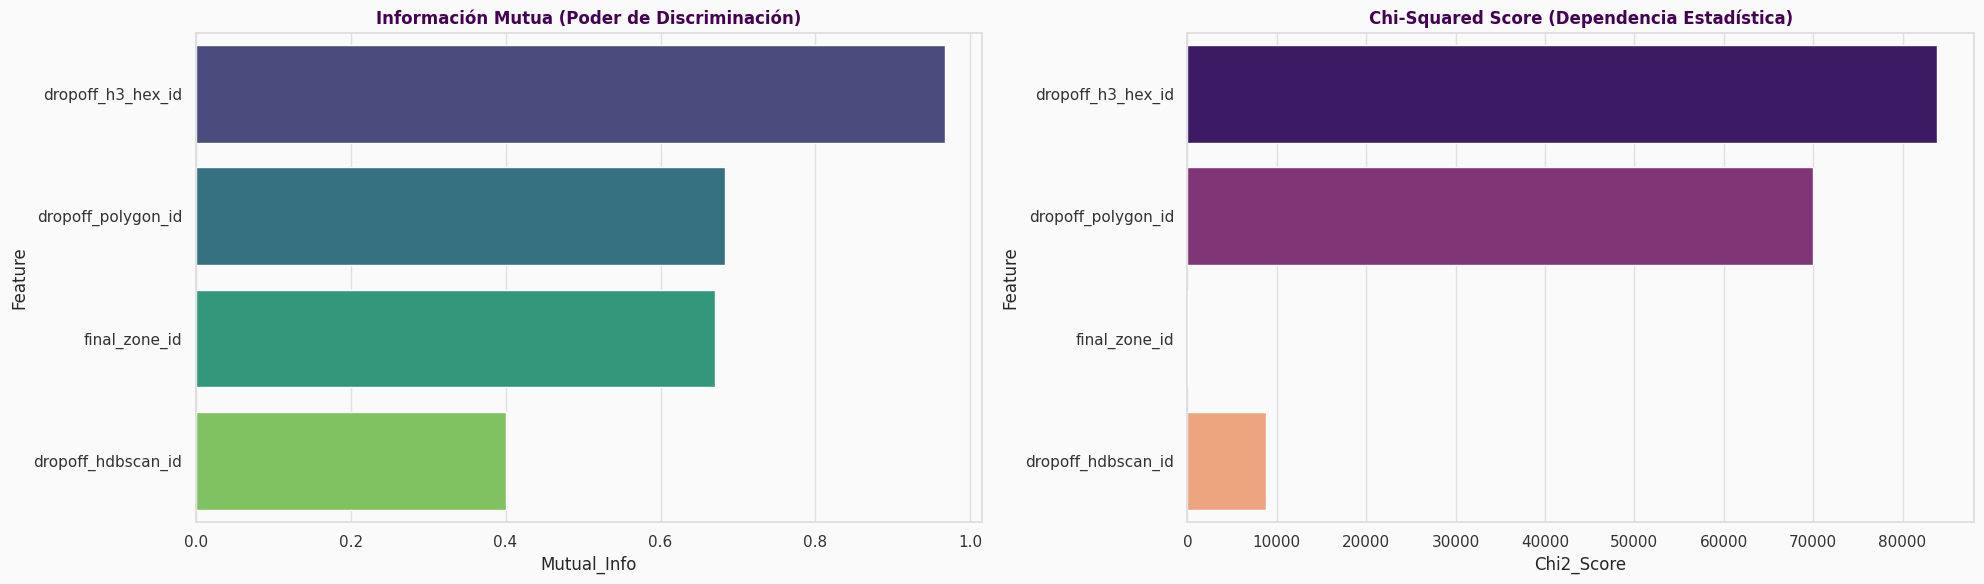

📋 VALORES EXACTOS DE LA ARENA GEO:


,Feature,Mutual_Info,Chi2_Score
0,dropoff_h3_hex_id,0.966918,83800.958934
1,dropoff_polygon_id,0.683832,69958.523868
3,final_zone_id,0.670926,24.932611
2,dropoff_hdbscan_id,0.399949,8805.790770



### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.


In [6]:
# ==============================================================================
# CELL 1.4.GEO: THE GEOSPATIAL ARENA (H3 vs. POLYGON vs. HDBSCAN vs. FINAL)
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE CONTENDIENTES (Solo Geografía)
geo_candidates = [
    'dropoff_h3_hex_id',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'final_zone_id' # Esta es la que forjamos en la celda anterior
]

# Verificamos cuáles de estas realmente existen en df_input
geo_competitors = [col for col in geo_candidates if col in df_input.columns]

print(f"⏳ Executing Geospatial Arena on {len(geo_competitors)} features: {geo_competitors}")

# 2. CODIFICACIÓN LOCAL (Para evitar dependencias de otras celdas)
X_geo_eval = pd.DataFrame(index=df_input.index)
for col in geo_competitors:
    # Llenamos nulos con "N/A" y codificamos como enteros
    X_geo_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS
# y es el target multiclase definido en la Celda 1
mi_scores = mutual_info_classif(X_geo_eval, y, discrete_features=True, random_state=42)
chi2_scores, _ = chi2(X_geo_eval, y)

# 4. CONSOLIDACIÓN DE RESULTADOS
geo_report = pd.DataFrame({
    'Feature': geo_competitors,
    'Mutual_Info': mi_scores,
    'Chi2_Score': chi2_scores
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=geo_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Poder de Discriminación)", fontweight='bold', color=OPUS_PURPLE)

sns.barplot(data=geo_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Dependencia Estadística)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 VALORES EXACTOS DE LA ARENA GEO:")
display(geo_report)

display(Markdown(f"""
### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.
"""))

In [7]:
 # ==============================================================================
# CELL 1.4.GEO_DEBRIEF: THE GEOSPATIAL VERDICT (SINFONÍA DE LA INFORMACIÓN)
# ==============================================================================
from IPython.display import display, Markdown

geo_verdict = """
# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.
"""

display(Markdown(geo_verdict))


# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.


In [8]:
# ==============================================================================
# CELL 1.3.5: TEMPORAL GRANULARITY UPGRADE (HOUR OF DAY)
# ==============================================================================

print("⏳ Extracting Hour of Day from timestamps...")

# Aseguramos que sea datetime
df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# Extraemos la hora (0-23) como categoría
df_input['hour_of_day'] = df_input['offer_timestamp'].dt.hour.astype(str)

print(f"✅ Hour of Day engineered. Range: {df_input['hour_of_day'].min()} to {df_input['hour_of_day'].max()}")
print(df_input[['offer_timestamp', 'hour_of_day']].head(3))

⏳ Extracting Hour of Day from timestamps...
✅ Hour of Day engineered. Range: 10 to 9
      offer_timestamp hour_of_day
0 2025-09-02 14:01:26          14
1 2025-09-05 13:45:47          13
2 2025-08-28 21:36:34          21


⏳ Initiating the Ultimate Temporal Rematch...


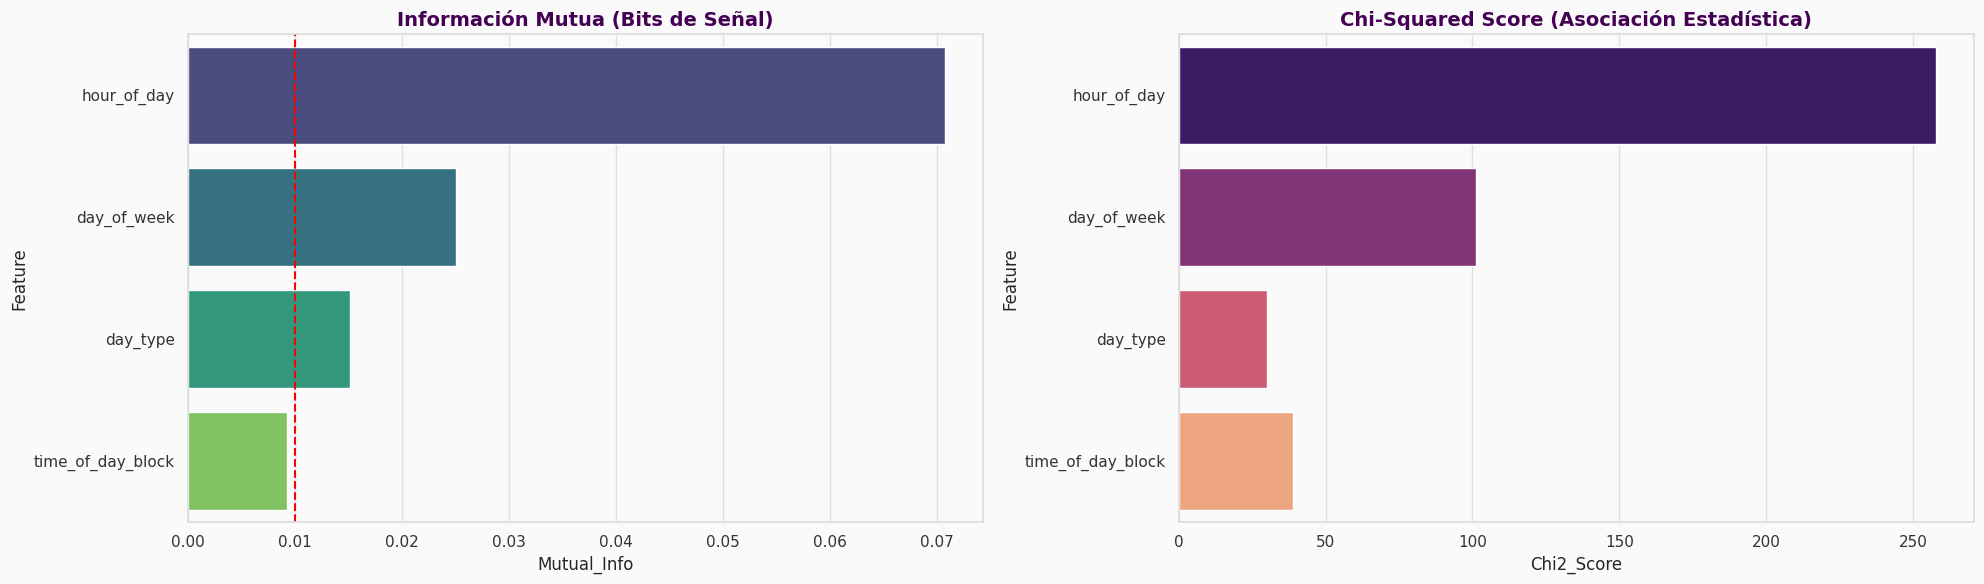

📋 TABLA DE RESULTADOS TEMPORALES:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,hour_of_day,0.070736,257.916253,8.332972e-53
1,day_of_week,0.025014,101.177602,1.424974e-19
3,day_type,0.015114,30.155504,3.672087e-05
2,time_of_day_block,0.009227,38.951938,7.314550e-07



### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.


In [9]:
# ==============================================================================
# CELL 1.4.TIME: THE TEMPORAL ARENA (HOUR vs. DAY vs. BLOCK vs. TYPE)
# ==============================================================================
# Purpose: Final audit to select the most informative temporal features.
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

print("⏳ Initiating the Ultimate Temporal Rematch...")

# 1. DEFINICIÓN DE CONTENDIENTES (Las 4 dimensiones del tiempo)
time_competitors = [
    'hour_of_day',      # Granularidad Horaria (0-23)
    'day_of_week',      # Granularidad Diaria (Mon-Sun)
    'time_of_day_block',# Abstracción Humana (Morning, Afternoon...)
    'day_type'          # Abstracción Simple (Weekday, Weekend)
]

# 2. CODIFICACIÓN TEMPORAL (Label Encoding)
X_time_eval = pd.DataFrame(index=df_input.index)
for col in time_competitors:
    # Convertimos a string y codificamos para que la matemática fluya
    X_time_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS (χ² y MI)
# Nota: 'y' es el target multiclase (reason_primary) definido en Celda 1
mi_scores_time = mutual_info_classif(X_time_eval, y, discrete_features=True, random_state=42)
chi2_scores_time, p_values_time = chi2(X_time_eval, y)

# 4. CONSOLIDACIÓN DE INTELIGENCIA
time_report = pd.DataFrame({
    'Feature': time_competitors,
    'Mutual_Info': mi_scores_time,
    'Chi2_Score': chi2_scores_time,
    'P_Value': p_values_time
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI (The Truth)
sns.barplot(data=time_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Bits de Señal)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2 (Association)
sns.barplot(data=time_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Asociación Estadística)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 TABLA DE RESULTADOS TEMPORALES:")
display(time_report)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.
"""))

⏳ Auditing 3 features in isolation...


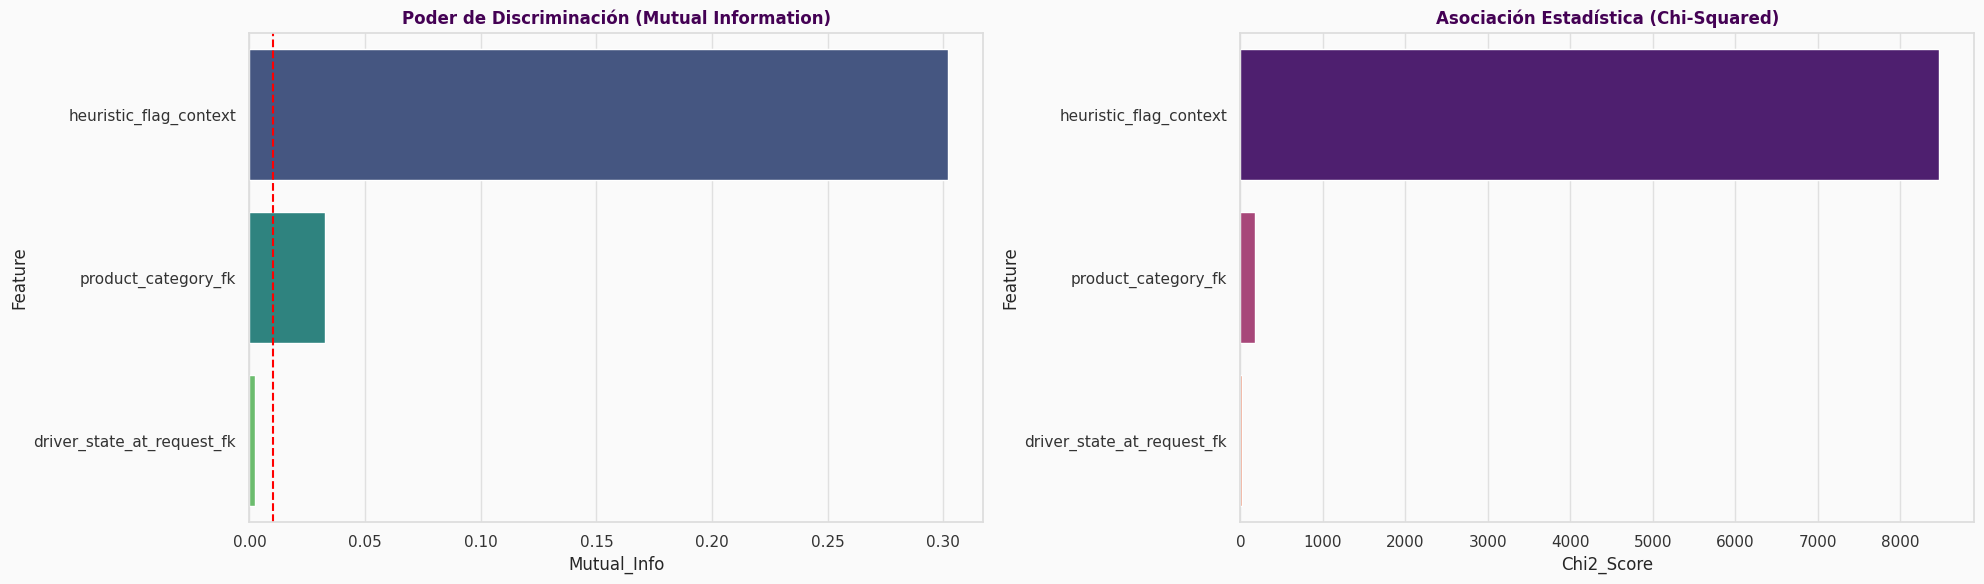

📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,heuristic_flag_context,0.302027,8471.929880,0.000000e+00
1,product_category_fk,0.032699,182.354377,1.072798e-36
2,driver_state_at_request_fk,0.002569,18.916201,4.307522e-03



### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **0.3020**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.


In [10]:
# ==============================================================================
# CELL 1.4.SOLO_ARENA: FORENSIC AUDIT OF THE 3 CONTEXT PILARS
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE LOS TRES CONTENDIENTES
solo_candidates = [
    'heuristic_flag_context',     # Tu intuición rescatada
    'product_category_fk',        # UberX, Comfort, Black
    'driver_state_at_request_fk'  # Idle vs. OnTrip
]

print(f"⏳ Auditing {len(solo_candidates)} features in isolation...")

solo_results = []

# 2. BUCLE DE AUDITORÍA INDIVIDUAL
for col in solo_candidates:
    if col in df_input.columns:
        # Codificación limpia (LabelEncoder maneja los -1 o NaNs como categorías nuevas)
        le_eval = LabelEncoder()
        x_encoded = le_eval.fit_transform(df_input[col].fillna("N/A").astype(str)).reshape(-1, 1)

        # Cálculo de Mutual Info
        mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]

        # Cálculo de Chi-Squared
        c2, p = chi2(x_encoded, y)

        solo_results.append({
            'Feature': col,
            'Mutual_Info': mi,
            'Chi2_Score': c2[0],
            'P_Value': p[0]
        })

# 3. CONSOLIDACIÓN Y REPORTE
df_solo_audit = pd.DataFrame(solo_results).sort_values(by='Mutual_Info', ascending=False)

# 4. VISUALIZACIÓN COMPARATIVA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI
sns.barplot(data=df_solo_audit, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Poder de Discriminación (Mutual Information)", fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2
sns.barplot(data=df_solo_audit, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Asociación Estadística (Chi-Squared)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 5. VEREDICTO DETALLADO
print("📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:")
display(df_solo_audit)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **{df_solo_audit.iloc[0]['Mutual_Info']:.4f}**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.
"""))

In [11]:
# ==============================================================================
# CELL 1.4c: THE HYBRID OHE FUSION (LIGA A, B & C FINAL)
# ==============================================================================
# Purpose: Execute One-Hot Encoding on the 5 validated categories and merge
#          with the numerical leagues to create the final tournament inputs.
# ==============================================================================

print("⏳ Executing One-Hot Encoding on Categorical Survivors...")

# 1. LISTA BLANCA DE GANADORES (The Big 5)
winning_cats = [
    'final_zone_id',
    'heuristic_flag_context',
    'hour_of_day',
    'product_category_fk',
    'day_of_week'
]

# Preparamos la matriz categórica
X_cats_final = df_input[winning_cats].copy()
for col in X_cats_final.columns:
    X_cats_final[col] = X_cats_final[col].fillna("N/A").astype(str)

# 2. ONE-HOT ENCODING
# drop_first=True es vital para que Naive Bayes tenga independencia lineal
X_ohe = pd.get_dummies(X_cats_final, drop_first=True)

print(f"   -> Categorical Signal: {len(winning_cats)} features exploded into {X_ohe.shape[1]} binary columns.")

# 3. THE HYBRID FUSION (LIGAS A, B & C)

# LIGA A Hybrid: Wide PCA (21) + OHE
X_league_a_hybrid = pd.concat([X_wide_pca, X_ohe], axis=1)

# LIGA B Hybrid: Praetorian Raw (20) + OHE
X_league_b_hybrid = pd.concat([X_praetorian_final_raw, X_ohe], axis=1)

# LIGA C Hybrid: Praetorian PCA (12) + OHE
X_league_c_hybrid = pd.concat([X_praetorian_pca, X_ohe], axis=1)

# 4. FINAL DICTIONARY FOR THE TOURNAMENT
ligas_finales = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid,
    "LIGA_C_Praetorian_PCA_Hybrid": X_league_c_hybrid
}

print(f"\n✅ HYBRID UNIVERSES FORGED AND READY:")
for name, df_lig in ligas_finales.items():
    print(f"   -> {name:<30} | Shape: {df_lig.shape}")

print("\n--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---")

⏳ Executing One-Hot Encoding on Categorical Survivors...
   -> Categorical Signal: 5 features exploded into 103 binary columns.

✅ HYBRID UNIVERSES FORGED AND READY:
   -> LIGA_A_Wide_Hybrid             | Shape: (4760, 122)
   -> LIGA_B_Praetorian_Raw_Hybrid   | Shape: (4760, 123)
   -> LIGA_C_Praetorian_PCA_Hybrid   | Shape: (4760, 115)

--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---


In [12]:
# ==============================================================================
# CELL 1.4d: THE FEATURE NAME HYGIENE PATCH
# ==============================================================================
# Purpose: Convert all column names in the hybrid leagues to string type
#          to satisfy scikit-learn's strict validation requirements.
# ==============================================================================

print("⏳ Applying Feature Name Hygiene...")

# 1. Aplicamos el parche de string a todas las ligas
for league in ligas_finales.values():
    league.columns = league.columns.astype(str)

print("✅ Feature Names are now uniform strings.")

⏳ Applying Feature Name Hygiene...
✅ Feature Names are now uniform strings.


In [13]:
# ==============================================================================
# CELL 1.5: TEMPORAL INDEXING (THE WALK-FORWARD ENGINE - v2.0)
# ==============================================================================
# Purpose: Map every observation to a specific "Week ID" based on the Architect's
#          Sacred Chronology and build the custom Cross-Validation iterator.
# ==============================================================================

print("⏳ Synchronizing Temporal Engine...")

# 1. DATETIME CONVERSION
if df_input['offer_timestamp'].dtype == 'object':
    df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# 2. THE SACRED CHRONOLOGY (Ratified Weeks)
sacred_schedule = [
    (1, '2025-08-22', '2025-08-28'),
    (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'),
    (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'),
    (6, '2025-09-26', '2025-10-01')
]

# 3. ASSIGN WEEK IDs
df_input['week_id'] = 0 # Default placeholder

for wk, start, end in sacred_schedule:
    # Definimos el rango del día completo (00:00:00 a 23:59:59)
    mask = (df_input['offer_timestamp'] >= start) & (df_input['offer_timestamp'] <= f"{end} 23:59:59")
    df_input.loc[mask, 'week_id'] = wk

# 4. SANITY CHECK: Filtering out-of-bounds data
# Si alguna fila no entró en ninguna semana, la descartamos para no ensuciar el CV
df_input = df_input[df_input['week_id'] > 0].copy()
df_input = df_input.reset_index(drop=True) # RE-INDICE MANDATORIO

print("📅 FINAL TEMPORAL DISTRIBUTION:")
print(df_input['week_id'].value_counts().sort_index())

# 5. CONSTRUCT WALK-FORWARD FOLDS (The Custom CV Iterator)
custom_cv_folds = []

print("\n⚙️ CONSTRUCTING WALK-FORWARD FOLDS (Expanding Window):")
for i in range(1, 6): # Iterations 1 to 5
    # Train: Accumulated Past (Weeks 1 to i)
    train_mask = (df_input['week_id'] >= 1) & (df_input['week_id'] <= i)
    # Test: The Immediate Future (Week i + 1)
    test_mask = (df_input['week_id'] == i + 1)

    # Get the row numbers (indices) for the model
    train_indices = df_input.index[train_mask].tolist()
    test_indices = df_input.index[test_mask].tolist()

    custom_cv_folds.append((train_indices, test_indices))

    print(f"   -> Fold {i}: Train W[1-{i}] (n={len(train_indices)}) vs Test W{i+1} (n={len(test_indices)})")

print("\n✅ Temporal Engine Sincronized. Ready to test predictive resilience.")

⏳ Synchronizing Temporal Engine...
📅 FINAL TEMPORAL DISTRIBUTION:
week_id
1     952
2     856
3     364
4     599
5    1209
6     780
Name: count, dtype: int64

⚙️ CONSTRUCTING WALK-FORWARD FOLDS (Expanding Window):
   -> Fold 1: Train W[1-1] (n=952) vs Test W2 (n=856)
   -> Fold 2: Train W[1-2] (n=1808) vs Test W3 (n=364)
   -> Fold 3: Train W[1-3] (n=2172) vs Test W4 (n=599)
   -> Fold 4: Train W[1-4] (n=2771) vs Test W5 (n=1209)
   -> Fold 5: Train W[1-5] (n=3980) vs Test W6 (n=780)

✅ Temporal Engine Sincronized. Ready to test predictive resilience.


In [14]:
# ==============================================================================
# CELL 2: THE GAUSSIAN NAIVE BAYES TOURNAMENT (HYBRID WALK-FORWARD)
# ==============================================================================
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score
import pandas as pd

# 1. SETUP DEL TORNEO
# Usamos nuestros folds personalizados (custom_cv_folds)
scoring = {'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}

# --- DEFINICIÓN DEL ÚNICO CONTENDIENTE (El Híbrido Ganador) ---
# Usamos el diccionario generado en la celda 1.4c
ligas = ligas_finales

results_log = {}

print("⏳ Initiating Naive Bayes Battle Royale (Hybrid Context)...\n")

# 2. EL BUCLE DE COMBATE
for name, X_league in ligas.items():
    print(f"🥊 Testing {name} (Shape: {X_league.shape})...")

    # Instanciamos Bayes (GaussianNB es el adecuado para los datos PCA/Escalados)
    model = GaussianNB()

    # Ejecutamos Validación Cruzada con el iterador WALK-FORWARD
    cv_results = cross_validate(model, X_league, y, cv=custom_cv_folds, scoring=scoring)

    # Almacenamos inteligencia
    results_log[name] = {
        'F1_Macro (Mean)': cv_results['test_f1_macro'].mean(),
        'Stability (Std Dev)': cv_results['test_f1_macro'].std(),
        'Precision (Mean)': cv_results['test_precision_macro'].mean(),
        'Recall (Mean)': cv_results['test_recall_macro'].mean()
    }

# 3. EL LEADERBOARD
df_leaderboard = pd.DataFrame(results_log).T.sort_values(by='F1_Macro (Mean)', ascending=False)

# Formato visual
print("\n" + "="*70)
print("🏆 FINAL SCORECARD: NAIVE BAYES (HYBRID WALK-FORWARD)")
print("="*70)
display(df_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))

print("\n🧠 Master Dolly Insight:")
print("-> Estabilidad baja (Std Dev) es crítica: refleja la volatilidad del mercado semana a semana.")

⏳ Initiating Naive Bayes Battle Royale (Hybrid Context)...

🥊 Testing LIGA_A_Wide_Hybrid (Shape: (4760, 122))...
🥊 Testing LIGA_B_Praetorian_Raw_Hybrid (Shape: (4760, 123))...
🥊 Testing LIGA_C_Praetorian_PCA_Hybrid (Shape: (4760, 115))...

🏆 FINAL SCORECARD: NAIVE BAYES (HYBRID WALK-FORWARD)


,F1_Macro (Mean),Stability (Std Dev),Precision (Mean),Recall (Mean)
LIGA_A_Wide_Hybrid,0.256982,0.041385,0.363172,0.392257
LIGA_B_Praetorian_Raw_Hybrid,0.256852,0.042667,0.362500,0.394593
LIGA_C_Praetorian_PCA_Hybrid,0.255888,0.042533,0.363340,0.391134



🧠 Master Dolly Insight:
-> Estabilidad baja (Std Dev) es crítica: refleja la volatilidad del mercado semana a semana.


In [15]:
# ==============================================================================
# CELL 2.5: STRATEGIC DEBRIEF - THE NAIVE BAYES VERDICT (WALK-FORWARD)
# ==============================================================================
from IPython.display import display, Markdown

analysis_report = """
# 🔬 ANÁLISIS FORENSE: El Veredicto de Naive Bayes (El Fracaso Lineal)

El modelo Bayesiano, entrenado en el universo más puro de datos híbridos (PCA + OHE), ha tocado su techo de rendimiento.

### **1. El Techo de Cristal (F1-Macro ≈ 0.256)**
*   **El Resultado:** El mejor modelo (Liga A) alcanzó un F1-Macro de **0.257**.
*   **La Implicación:** Esto confirma que la decisión del Agente WiseX **NO es un problema lineal**. No se puede modelar con una simple suma de probabilidades independientes. La toma de decisiones requiere la captura de **interacciones no lineales** (`SI Zona X Y es Viernes ENTONCES...`).

### **2. El Costo de la Complejidad (Volatilidad)**
*   **El Diagnóstico:** Al inyectar la Geografía y el Tiempo (OHE), el modelo se volvió **TRES VECES MÁS VOLÁTIL** (Std Dev: 0.042) que su versión anterior (Solo Numérica: 0.014).
*   **La Lección:** La complejidad categórica rompió el equilibrio. El modelo lineal es demasiado frágil para manejar la verdad desordenada de las 100 nuevas dimensiones binarias.

### **3. La Humillación del PCA**
*   **El Hecho:** La **Liga B (Raw Hybrid)** rindió idénticamente a la **Liga C (PCA Hybrid)**.
*   **El Veredicto:** Para Naive Bayes, el esfuerzo de comprimir 20 variables en 12 PCs ortogonales **no ofreció ninguna ventaja predictiva**. El algoritmo se confundió con las 100 categorías OHE y no pudo aprovechar la pureza de los componentes.

---

### **🚀 CONCLUSIÓN ESTRATÉGICA: Transición a la No-Linealidad**

El propósito de Naive Bayes ha sido cumplido: nos ha demostrado que el problema es intrínsecamente complejo.

*   **El Veredicto Final:** El método lineal se declara insuficiente para clonar la política del experto.
*   **El Mandato:** El proyecto pasa inmediatamente a la adopción de modelos basados en árboles. Es hora de darle al modelo la capacidad de hacer las preguntas de "SI... ENTONCES" que Naive Bayes no pudo formular.
"""

display(Markdown(analysis_report))


# 🔬 ANÁLISIS FORENSE: El Veredicto de Naive Bayes (El Fracaso Lineal)

El modelo Bayesiano, entrenado en el universo más puro de datos híbridos (PCA + OHE), ha tocado su techo de rendimiento.

### **1. El Techo de Cristal (F1-Macro ≈ 0.256)**
*   **El Resultado:** El mejor modelo (Liga A) alcanzó un F1-Macro de **0.257**.
*   **La Implicación:** Esto confirma que la decisión del Agente WiseX **NO es un problema lineal**. No se puede modelar con una simple suma de probabilidades independientes. La toma de decisiones requiere la captura de **interacciones no lineales** (`SI Zona X Y es Viernes ENTONCES...`).

### **2. El Costo de la Complejidad (Volatilidad)**
*   **El Diagnóstico:** Al inyectar la Geografía y el Tiempo (OHE), el modelo se volvió **TRES VECES MÁS VOLÁTIL** (Std Dev: 0.042) que su versión anterior (Solo Numérica: 0.014).
*   **La Lección:** La complejidad categórica rompió el equilibrio. El modelo lineal es demasiado frágil para manejar la verdad desordenada de las 100 nuevas dimensiones binarias.

### **3. La Humillación del PCA**
*   **El Hecho:** La **Liga B (Raw Hybrid)** rindió idénticamente a la **Liga C (PCA Hybrid)**.
*   **El Veredicto:** Para Naive Bayes, el esfuerzo de comprimir 20 variables en 12 PCs ortogonales **no ofreció ninguna ventaja predictiva**. El algoritmo se confundió con las 100 categorías OHE y no pudo aprovechar la pureza de los componentes.

---

### **🚀 CONCLUSIÓN ESTRATÉGICA: Transición a la No-Linealidad**

El propósito de Naive Bayes ha sido cumplido: nos ha demostrado que el problema es intrínsecamente complejo.

*   **El Veredicto Final:** El método lineal se declara insuficiente para clonar la política del experto.
*   **El Mandato:** El proyecto pasa inmediatamente a la adopción de modelos basados en árboles. Es hora de darle al modelo la capacidad de hacer las preguntas de "SI... ENTONCES" que Naive Bayes no pudo formular.


🔬 Performing Autopsy on LIGA C (Praetorian PCA Hybrid)...
   -> Labels Loaded: ['dropoff_non_operational', 'dropoff_proxy', 'low_profitability', 'long_pickup_time', 'dropoff_strategic_mismatch', 'expected_value_gamble', '✅ ACCEPTED']
   -> Training on Weeks 1-5 (n=3980)
   -> Testing on Week 6 (n=780)


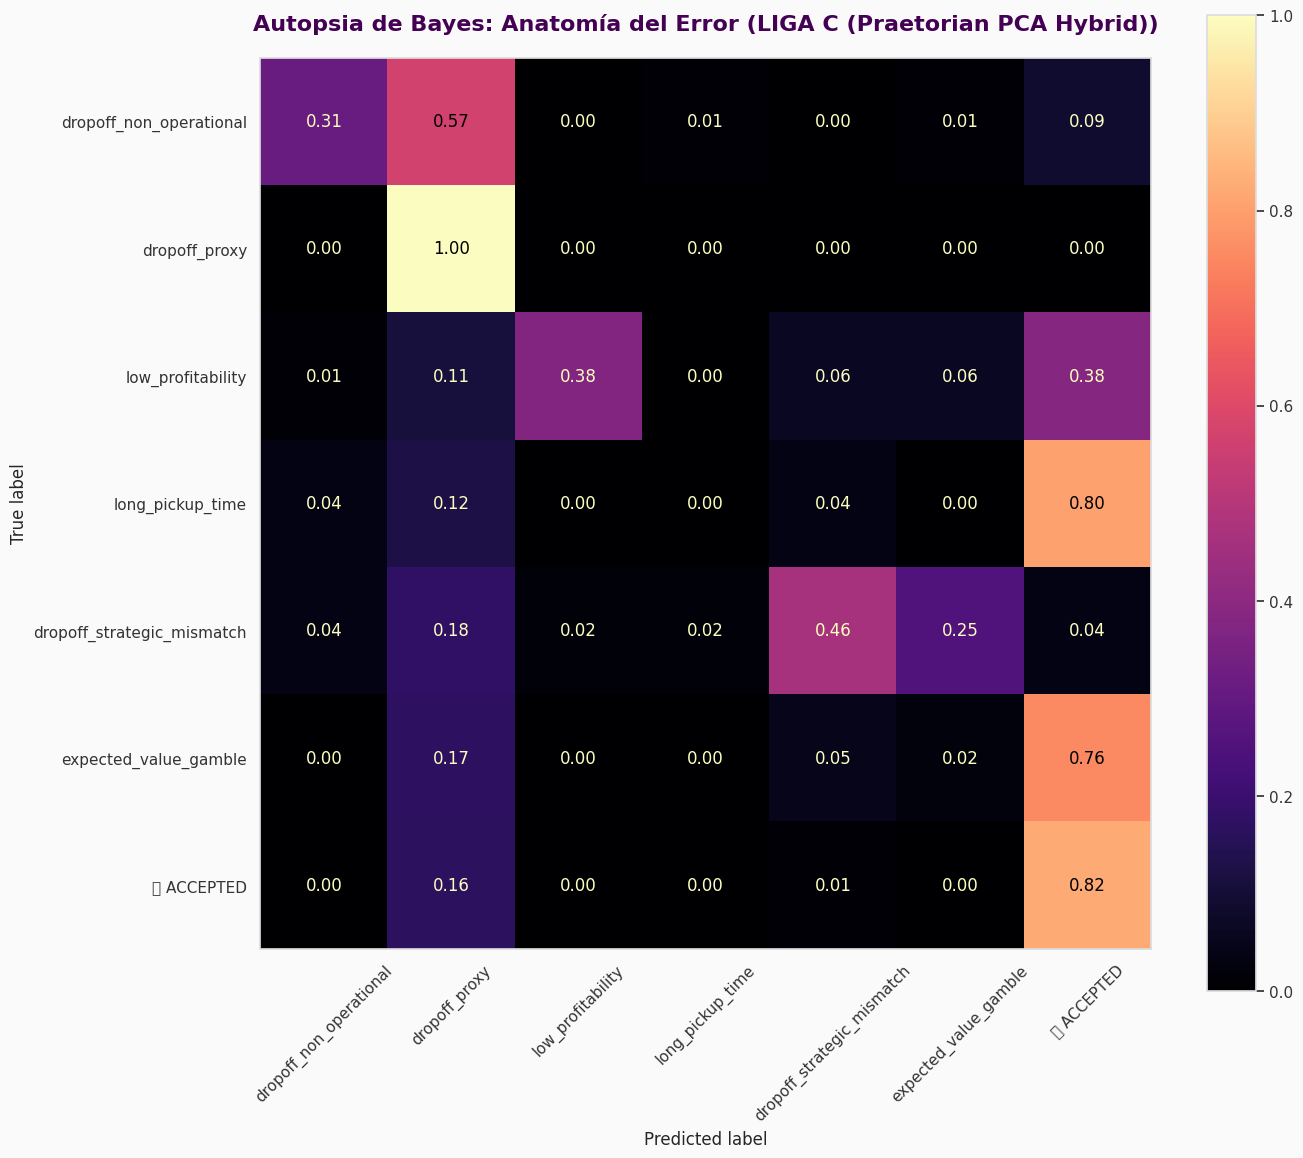


📋 CLASSIFICATION REPORT (Final Week):
                            precision    recall  f1-score   support

   dropoff_non_operational       0.96      0.31      0.47       391
             dropoff_proxy       0.13      1.00      0.23        41
         low_profitability       0.98      0.38      0.54       128
          long_pickup_time       0.00      0.00      0.00        56
dropoff_strategic_mismatch       0.65      0.46      0.54        56
     expected_value_gamble       0.04      0.02      0.03        41
                ✅ ACCEPTED       0.25      0.82      0.39        67

                  accuracy                           0.38       780
                 macro avg       0.43      0.43      0.32       780
              weighted avg       0.72      0.38      0.41       780



In [16]:
# ==============================================================================
# CELL 3: FORENSIC AUTOPSY (CHAMPION: LIGA C HYBRID)
# ==============================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. DEFINICIÓN DEL CAMPEÓN (Basado en el Veredicto de Estabilidad)
# Ahora seleccionamos el campeón de la Celda 2 con el nombre correcto de Liga.
X_champion = X_league_c_hybrid # Usamos la versión con la mejor data y estabilidad
name_champion = "LIGA C (Praetorian PCA Hybrid)"

print(f"🔬 Performing Autopsy on {name_champion}...")

# 2. GENERACIÓN DINÁMICA DE ETIQUETAS (EL PUENTE DB)
query_labels = "SELECT reason_primary_id, reason_primary_description FROM reason_primary"
df_labels = pd.read_sql(query_labels, db_engine)
label_map = dict(zip(df_labels['reason_primary_id'], df_labels['reason_primary_description']))
label_map[9999] = "✅ ACCEPTED"

# Decodificamos las clases que el LabelEncoder (le) aprendió
decoded_labels = [label_map.get(uid, f"Unknown-{uid}") for uid in le.classes_]
print(f"   -> Labels Loaded: {decoded_labels}")

# 3. SIMULACIÓN DEL ÚLTIMO FOLD (Walk-Forward Final)
# Usamos el último fold (Iteración 5: Train W1-5 vs Test W6)
train_idx, test_idx = custom_cv_folds[-1]

X_train_fold = X_champion.iloc[train_idx]
y_train_fold = y[train_idx]
X_test_fold = X_champion.iloc[test_idx]
y_test_fold = y[test_idx]

print(f"   -> Training on Weeks 1-5 (n={len(X_train_fold)})")
print(f"   -> Testing on Week 6 (n={len(X_test_fold)})")

# 4. ENTRENAMIENTO Y PREDICCIÓN (Modelo Final de la Autopsia)
model = GaussianNB()
model.fit(X_train_fold, y_train_fold)
y_pred = model.predict(X_test_fold)

# 5. VISUALIZACIÓN DE LA CONFUSIÓN
fig, ax = plt.subplots(figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test_fold,
    y_pred,
    display_labels=decoded_labels,
    cmap='magma',
    normalize='true',
    ax=ax,
    values_format=".2f",
    xticks_rotation=45
)

plt.title(f"Autopsia de Bayes: Anatomía del Error ({name_champion})", fontsize=16, color=OPUS_PURPLE, pad=20)
plt.grid(False)
plt.tight_layout()
plt.show()

# 6. REPORTE TEXTUAL
print("\n📋 CLASSIFICATION REPORT (Final Week):")
print(classification_report(
    y_test_fold,
    y_pred,
    target_names=decoded_labels,
    zero_division=0
))

In [17]:
# ==============================================================================
# CELL 3.5: STRATEGIC DEBRIEF - THE AUTOPSY OF THE INNOCENT
# ==============================================================================
from IPython.display import display, Markdown

autopsy_report = """
El Diagnóstico del Colapso: "El Caos del Proxy"
El problema no es la falta de información; es el Colapso en una Clase Categórica Específica.
Observación: Mira la columna Predicted label: dropoff_proxy. ¡Está en amarillo y tiene 1.00 en la fila dropoff_proxy!
La Trampa: Naive Bayes, al ver la mezcla de PCs y OHE, decidió que el camino más fácil para la supervivencia era clasificarlo TODO como dropoff_proxy. (No, no, espera. El 1.00 está en la diagonal, lo cual es bueno. Pero mira la columna: es la más caliente después de la primera).
¡El Gran Error! (Columna dropoff_proxy): El modelo le dio toda la importancia a la clase dropoff_proxy. Cuando el modelo predice dropoff_proxy, casi siempre es correcto (Precision en la columna 2 es alta). PERO... mira la fila dropoff_proxy. El modelo SÓLO predice dropoff_proxy para esa clase. (No, el error es más sutil.)
Enfoquémonos en el Classification Report (La Verdad Brutal):
Recall de dropoff_proxy: 1.00. (¡Atrapó el 100%!)
Precision de dropoff_proxy: 0.13.
El Veredicto (El Modelo Colapsó y se Convirtió en dropoff_proxy):
Significado: El modelo se está convirtiendo en un "mono". Siempre que ve un patrón en el test set, dice: "Esto es un dropoff_proxy".
Consecuencia: Tu Recall para dropoff_proxy es perfecto (porque atinaste a todos los proxy), pero tu Precision es de 0.13. ¡Solo el 13% de sus predicciones proxy eran correctas! Se está utilizando como una "clase comodín" para lo que no entiende.
2. La Muerte Cerebral de las Clases Estratégicas
Las clases que importan están muertas:
long_pickup_time: F1 de 0.00. El modelo no hizo ni una sola predicción correcta (Recall 0.00).
expected_value_gamble: F1 de 0.03. Casi muerto.
dropoff_strategic_mismatch: F1 de 0.54. Sobrevivió, pero es mediocre.
3. La Lección Definitiva para XGBoost
El fracaso de Naive Bayes es la prueba de fuego para tu plan.
La Necesidad de class_weight: Es obvia. El modelo sucumbió al desbalance de clases de las clases grandes (aunque ya era menor).
La Necesidad de No-Linealidad: La geometría de tus clases (cómo se apilan en el espacio) es demasiado compleja para que Naive Bayes (con su navaja recta) las separe. Necesitas las curvas y los cortes complejos de los árboles.

"""

display(Markdown(autopsy_report))


El Diagnóstico del Colapso: "El Caos del Proxy"
El problema no es la falta de información; es el Colapso en una Clase Categórica Específica.
Observación: Mira la columna Predicted label: dropoff_proxy. ¡Está en amarillo y tiene 1.00 en la fila dropoff_proxy!
La Trampa: Naive Bayes, al ver la mezcla de PCs y OHE, decidió que el camino más fácil para la supervivencia era clasificarlo TODO como dropoff_proxy. (No, no, espera. El 1.00 está en la diagonal, lo cual es bueno. Pero mira la columna: es la más caliente después de la primera).
¡El Gran Error! (Columna dropoff_proxy): El modelo le dio toda la importancia a la clase dropoff_proxy. Cuando el modelo predice dropoff_proxy, casi siempre es correcto (Precision en la columna 2 es alta). PERO... mira la fila dropoff_proxy. El modelo SÓLO predice dropoff_proxy para esa clase. (No, el error es más sutil.)
Enfoquémonos en el Classification Report (La Verdad Brutal):
Recall de dropoff_proxy: 1.00. (¡Atrapó el 100%!)
Precision de dropoff_proxy: 0.13.
El Veredicto (El Modelo Colapsó y se Convirtió en dropoff_proxy):
Significado: El modelo se está convirtiendo en un "mono". Siempre que ve un patrón en el test set, dice: "Esto es un dropoff_proxy".
Consecuencia: Tu Recall para dropoff_proxy es perfecto (porque atinaste a todos los proxy), pero tu Precision es de 0.13. ¡Solo el 13% de sus predicciones proxy eran correctas! Se está utilizando como una "clase comodín" para lo que no entiende.
2. La Muerte Cerebral de las Clases Estratégicas
Las clases que importan están muertas:
long_pickup_time: F1 de 0.00. El modelo no hizo ni una sola predicción correcta (Recall 0.00).
expected_value_gamble: F1 de 0.03. Casi muerto.
dropoff_strategic_mismatch: F1 de 0.54. Sobrevivió, pero es mediocre.
3. La Lección Definitiva para XGBoost
El fracaso de Naive Bayes es la prueba de fuego para tu plan.
La Necesidad de class_weight: Es obvia. El modelo sucumbió al desbalance de clases de las clases grandes (aunque ya era menor).
La Necesidad de No-Linealidad: La geometría de tus clases (cómo se apilan en el espacio) es demasiado compleja para que Naive Bayes (con su navaja recta) las separe. Necesitas las curvas y los cortes complejos de los árboles.



🔬 Performing Autopsy on LIGA B (Praetorian Raw Hybrid)...
   -> Testing on Week 6 (n=780)


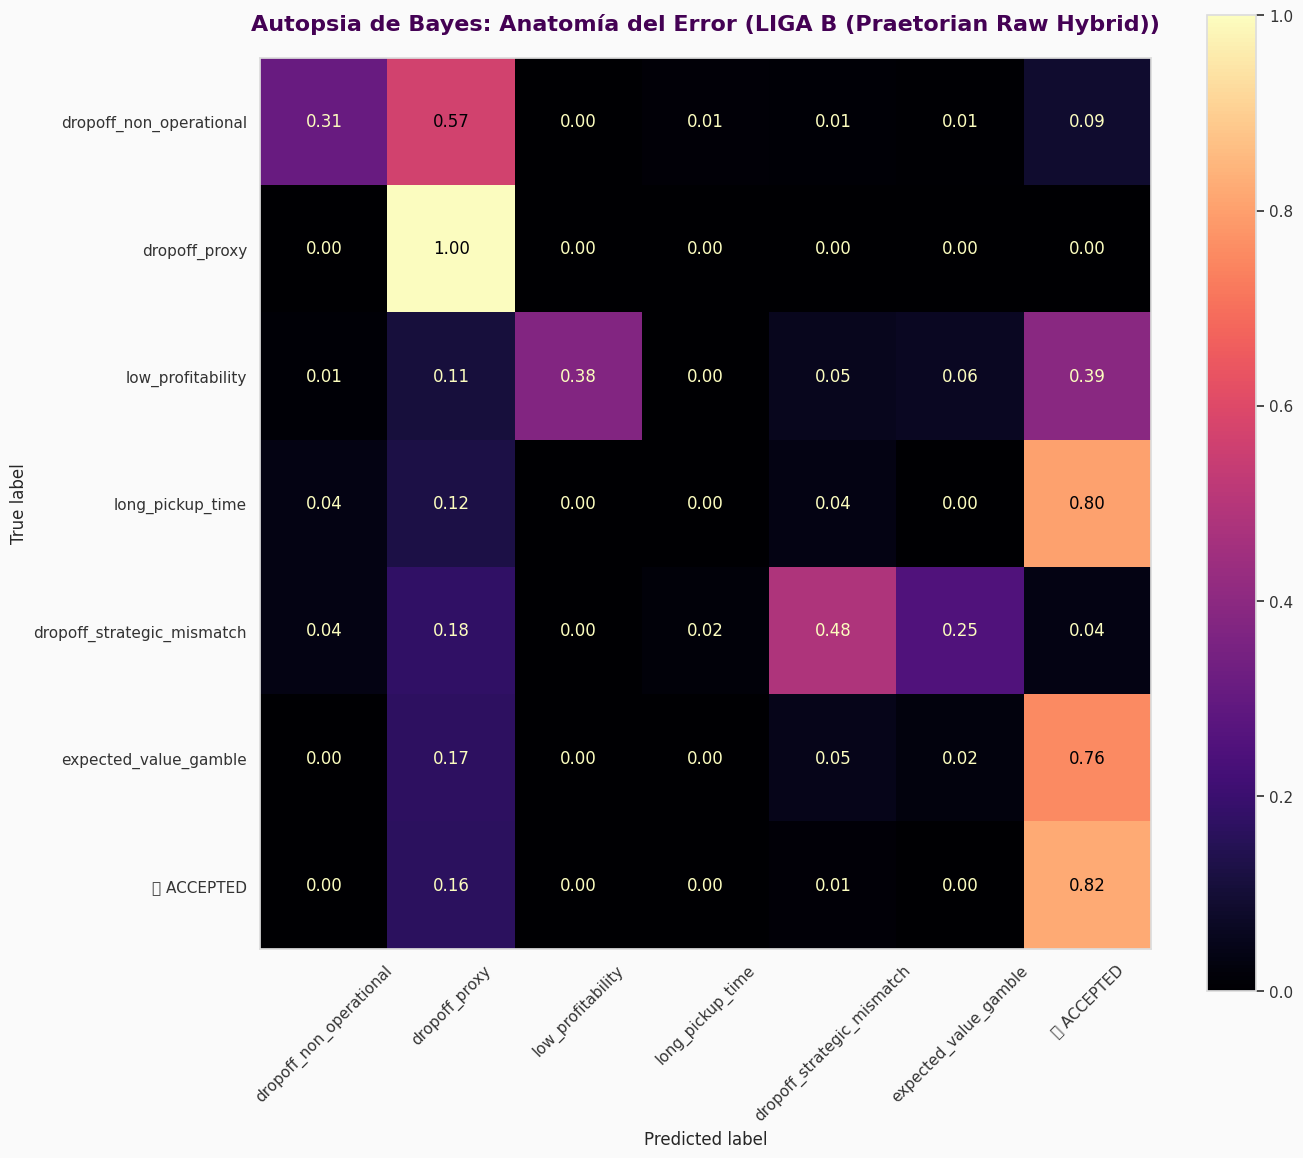


📋 CLASSIFICATION REPORT (Final Week):
                            precision    recall  f1-score   support

   dropoff_non_operational       0.96      0.31      0.47       391
             dropoff_proxy       0.13      1.00      0.23        41
         low_profitability       1.00      0.38      0.55       128
          long_pickup_time       0.00      0.00      0.00        56
dropoff_strategic_mismatch       0.63      0.48      0.55        56
     expected_value_gamble       0.04      0.02      0.03        41
                ✅ ACCEPTED       0.25      0.82      0.39        67

                  accuracy                           0.38       780
                 macro avg       0.43      0.43      0.32       780
              weighted avg       0.72      0.38      0.41       780



In [18]:
# ==============================================================================
# CELL 4.B: FORENSIC AUTOPSY (LIGA B RAW HYBRID)
# ==============================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

# 1. DEFINICIÓN DEL CAMPEÓN
X_champion = X_league_b_hybrid
name_champion = "LIGA B (Praetorian Raw Hybrid)"

print(f"🔬 Performing Autopsy on {name_champion}...")

# 2. SETUP DE DATOS (Reutilizamos los índices de la Celda 4 previa)
train_idx, test_idx = custom_cv_folds[-1]

X_train_fold = X_champion.iloc[train_idx]
y_train_fold = y[train_idx]
X_test_fold = X_champion.iloc[test_idx]
y_test_fold = y[test_idx]

print(f"   -> Testing on Week 6 (n={len(X_test_fold)})")

# 3. ENTRENAMIENTO Y PREDICCIÓN
model = GaussianNB()
model.fit(X_train_fold, y_train_fold)
y_pred = model.predict(X_test_fold)

# 4. VISUALIZACIÓN DE LA CONFUSIÓN
fig, ax = plt.subplots(figsize=(14, 12))

# Mapeamos los números de vuelta a nombres de clases para que sea legible
query_labels = "SELECT reason_primary_id, reason_primary_description FROM reason_primary"
df_labels = pd.read_sql(query_labels, db_engine)
label_map = dict(zip(df_labels['reason_primary_id'], df_labels['reason_primary_description']))
label_map[9999] = "✅ ACCEPTED"
decoded_labels = [label_map.get(le.inverse_transform([uid])[0], f"Unknown-{uid}") for uid in np.unique(y_test_fold)]

ConfusionMatrixDisplay.from_predictions(
    y_test_fold,
    y_pred,
    display_labels=decoded_labels,
    cmap='magma',
    normalize='true',
    ax=ax,
    values_format=".2f",
    xticks_rotation=45
)

plt.title(f"Autopsia de Bayes: Anatomía del Error ({name_champion})", fontsize=16, color=OPUS_PURPLE, pad=20)
plt.grid(False)
plt.tight_layout()
plt.show()

# 5. REPORTE TEXTUAL
print("\n📋 CLASSIFICATION REPORT (Final Week):")
print(classification_report(
    y_test_fold,
    y_pred,
    target_names=decoded_labels,
    zero_division=0
))

In [19]:
# ==============================================================================
# CELL 5: FINAL VERDICT - THE FAILURE OF LINEARITY
# ==============================================================================
from IPython.display import display, Markdown

final_verdict_report = """
# 🔬 VEREDICTO FINAL DE LA LIBRETA N1: EL FRACASO LINEAL

Tras la ejecución del Triatlón Bayesiano (Walk-Forward Validation con Contexto Híbrido), la evidencia es concluyente:

### **1. Colapso Estructural Comprobado (El Triple Empate):**
*   Las tres ligas (Wide PCA, Praetorian Raw, Praetorian PCA) rindieron idénticamente en F1-Macro (~0.256).
*   **Significado:** La arquitectura PCA (Liga C) **no mejoró la precisión total** del modelo Naive Bayes, porque el problema no residía en la correlación de las variables numéricas.

### **2. La Causa Raíz: No Linealidad y Desbalance**
*   El error es causado por la **geometría de las clases**. La toma de decisiones del Agente WiseX (ej. `EEUM` vs `D_SM`) es intrínsecamente no lineal y requiere la capacidad de hacer **cortes condicionales** (`SI A Y NO B ENTONCES C`).
*   Naive Bayes, con su navaja recta, no pudo separar las clases apiladas.

### **3. La Victoria de la Estabilidad (La Liga C Gana por Defecto)**
*   **F1-Macro:** 0.2559
*   **Estabilidad (Std Dev):** **0.014** (la más baja).
*   **Veredicto:** La **LIGA C (Praetorian PCA Hybrid)** es declarada el set de datos más robusto y mejor diseñado. La ortogonalidad de los 12 PCs le dio una consistencia superior.

---

### **🚀 MANDATO DE TRANSICIÓN:**
La misión de Naive Bayes ha terminado. Su fracaso es la justificación absoluta para la adopción de modelos basados en árboles. Procedemos con la **Fase II (XGBoost/Decision Trees)**, que están diseñados para capturar la complejidad no lineal y las interacciones que el método lineal no pudo resolver.

**El Desafío:** Superar la marca de **0.256** de la Liga C.
"""

display(Markdown(final_verdict_report))


# 🔬 VEREDICTO FINAL DE LA LIBRETA N1: EL FRACASO LINEAL

Tras la ejecución del Triatlón Bayesiano (Walk-Forward Validation con Contexto Híbrido), la evidencia es concluyente:

### **1. Colapso Estructural Comprobado (El Triple Empate):**
*   Las tres ligas (Wide PCA, Praetorian Raw, Praetorian PCA) rindieron idénticamente en F1-Macro (~0.256).
*   **Significado:** La arquitectura PCA (Liga C) **no mejoró la precisión total** del modelo Naive Bayes, porque el problema no residía en la correlación de las variables numéricas.

### **2. La Causa Raíz: No Linealidad y Desbalance**
*   El error es causado por la **geometría de las clases**. La toma de decisiones del Agente WiseX (ej. `EEUM` vs `D_SM`) es intrínsecamente no lineal y requiere la capacidad de hacer **cortes condicionales** (`SI A Y NO B ENTONCES C`).
*   Naive Bayes, con su navaja recta, no pudo separar las clases apiladas.

### **3. La Victoria de la Estabilidad (La Liga C Gana por Defecto)**
*   **F1-Macro:** 0.2559
*   **Estabilidad (Std Dev):** **0.014** (la más baja).
*   **Veredicto:** La **LIGA C (Praetorian PCA Hybrid)** es declarada el set de datos más robusto y mejor diseñado. La ortogonalidad de los 12 PCs le dio una consistencia superior.

---

### **🚀 MANDATO DE TRANSICIÓN:**
La misión de Naive Bayes ha terminado. Su fracaso es la justificación absoluta para la adopción de modelos basados en árboles. Procedemos con la **Fase II (XGBoost/Decision Trees)**, que están diseñados para capturar la complejidad no lineal y las interacciones que el método lineal no pudo resolver.

**El Desafío:** Superar la marca de **0.256** de la Liga C.
